In [17]:
# imports
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from joblib import parallel_backend
from joblib import dump
#from sklearn.linear_model import LogisticRegression
#from sklearn.linear_model import Lasso
#from sklearn.linear_model import Ridge
#from sklearn.ensemble import HistGradientBoostingClassifier
#from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

In [19]:
df = pd.read_csv("~/Documents/CMU/Computational Modeling/project/Epilepsy_dataset.csv")

In [3]:
y = df["Target/Epilepsy Type"]
x = df.drop(columns=["Target/Epilepsy Type"])

In [4]:
numeric_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=['object', 'category']).columns
print(numeric_cols)
print(categorical_cols)

# Program took seizure frequency and duration to be numeric - however, on closer inspection they seem to be categorical numeric values. 
# We will include them in the categorical variables 
x['Seizure Frequency'] = x['Seizure Frequency'].astype('category')
x['Seizure Duration'] = x['Seizure Duration'].astype('category')

numeric_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=['object', 'category']).columns
print(f"\nFinal numeric cols:", numeric_cols)
print(f"Final categorical cols:", categorical_cols)

# further extracting binary categorical columns from categorical_cols
binary_cols = [col for col in categorical_cols if x[col].nunique() == 2]
multi_cat_cols = [col for col in categorical_cols if x[col].nunique() > 2]

binary_df = x[binary_cols].copy()
multi_cat_df = x[multi_cat_cols].copy()
numeric_df = x[numeric_cols].copy()

print(f"\nShape of binary_df:", binary_df.shape)
print(f"Shape of multi_cat_df:", multi_cat_df.shape)
print(f"Shape of numeric_df:", numeric_df.shape)

Index(['Age', 'Weight', 'Height', 'Seizure Frequency', 'Seizure Duration'], dtype='object')
Index(['Gender', 'Medication Status', 'Alcohol or Drug Use',
       'EEG Abnormality Detected', 'MRI/CT Scan Result', 'Seizure Type',
       'Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness',
       'Jerky Movements', 'Postictal Confusion', 'Blank Stare Episodes',
       'Eye Rolling', 'Stress or Anxiety Before Episode',
       'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity',
       'Loud Sound Sensitivity', 'Missed Medication',
       'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor',
       'History of Stroke', 'Genetic Disorder',
       'Developmental Delay (in Children)'],
      dtype='object')

Final numeric cols: Index(['Age', 'Weight', 'Height'], dtype='object')
Final categorical cols: Index(['Gender', 'Medication Status', 'Alcohol or Drug Use',
       'EEG Abnormality Detected', 'MRI/CT Scan Result', 'Seizure Frequency',
       'Seizure Dur

In [5]:
for col in binary_cols:
    binary_df[col], _ = pd.factorize(binary_df[col])

binary_df.head

<bound method NDFrame.head of       Medication Status  Alcohol or Drug Use  EEG Abnormality Detected  \
0                     0                    0                         0   
1                     0                    1                         0   
2                     0                    1                         0   
3                     1                    1                         0   
4                     0                    1                         0   
...                 ...                  ...                       ...   
4851                  0                    1                         0   
4852                  0                    0                         0   
4853                  0                    1                         0   
4854                  0                    1                         1   
4855                  1                    1                         1   

      Aura Before Seizure  Loss of Consciousness  Muscle Stiffness  \
0          

In [6]:
y = df['Target/Epilepsy Type']
X = df.drop(columns = ['Target/Epilepsy Type'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
multi_cat_encoded = pd.get_dummies(multi_cat_df, drop_first=False,dtype=int)

count = 0
for col in multi_cat_cols:
    print("Unique values in", col, ":", multi_cat_df[col].unique())
    count += multi_cat_df[col].nunique()

print("\nTotal number of expected columns in multi_cat_encoded:", count)
print("\nActual shape of multi_cat_encoded:", multi_cat_encoded.shape)
print("\n")
print(multi_cat_encoded.head())

Unique values in Gender : ['Male' 'Female' 'Other']
Unique values in MRI/CT Scan Result : ['Normal' 'Abnormal' 'Not Done']
Unique values in Seizure Frequency : [1, 3, 0, 2, 5, 10]
Categories (6, int64): [0, 1, 2, 3, 5, 10]
Unique values in Seizure Duration : [60, 30, 90, 120]
Categories (4, int64): [30, 60, 90, 120]
Unique values in Seizure Type : ['Tonic-Clonic' 'Generalized' 'Focal' 'Absence']

Total number of expected columns in multi_cat_encoded: 20

Actual shape of multi_cat_encoded: (4856, 20)


   Gender_Female  Gender_Male  Gender_Other  MRI/CT Scan Result_Abnormal  \
0              0            1             0                            0   
1              1            0             0                            1   
2              1            0             0                            1   
3              1            0             0                            0   
4              0            1             0                            0   

   MRI/CT Scan Result_Normal  MRI/CT

In [8]:
# Putting all predictors back together 
x_processed = pd.concat([numeric_df, binary_df, multi_cat_encoded], axis=1)
print(x_processed.head())

# Split into training and test sets 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, stratify=y, random_state=42)
print("\n")
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Changing the categories into numeric codes for modelling
y_train = y_train.astype("category").cat.codes
y_test  = y_test.astype("category").cat.codes

   Age  Weight  Height  Medication Status  Alcohol or Drug Use  \
0   15    48.3   168.2                  0                    0   
1    4    56.0   174.5                  0                    1   
2   36    44.8   156.2                  0                    1   
3   32    70.4   180.4                  1                    1   
4   29    54.5   161.7                  0                    1   

   EEG Abnormality Detected  Aura Before Seizure  Loss of Consciousness  \
0                         0                    0                      0   
1                         0                    1                      0   
2                         0                    1                      1   
3                         0                    1                      0   
4                         0                    0                      0   

   Muscle Stiffness  Jerky Movements  ...  Seizure Frequency_5  \
0                 0                0  ...                    0   
1                 1 

In [15]:
# === CORRECTED FINAL MODEL PIPELINE (Option A - Recommended) ===

# Reset to raw data - NO manual preprocessing needed
X = df.drop(columns=['Target/Epilepsy Type'])
y = df['Target/Epilepsy Type']

# Split raw data directly
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Define features based on RAW X (this matches ColumnTransformer)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(exclude=['int64', 'float64']).columns

print("Numeric features:", numeric_features.tolist())
print("Categorical features:", categorical_features.tolist())
print(f"X_train shape: {X_train.shape}")

# Preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# AdaBoost model
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Full pipeline
m = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', adaboost_model)
])

# Grid search parameters
param_grid = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'classifier__estimator__max_depth': [1, 2, 3, 4]
}

# Run grid search
grid_search = GridSearchCV(
    m, param_grid, cv=5, scoring='accuracy', 
    verbose=2, n_jobs=-1, error_score='raise'
)
grid_search.fit(X_train, y_train)  # Now works with raw X_train!

# Results
best_pipeline = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

# Calibration and predictions
calibrated_model = CalibratedClassifierCV(best_pipeline, method='isotonic', cv='prefit')
calibrated_model.fit(X_train, y_train)

y_pred_test = calibrated_model.predict(X_test)
y_prob_test = calibrated_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Test accuracy: {test_accuracy:.3f}")

from sklearn.metrics import f1_score
w_f1 = f1_score(y_test, y_pred_test, average='weighted')
print(f"Weighted F1: {w_f1:.3f}")

Numeric features: ['Age', 'Weight', 'Height', 'Seizure Frequency', 'Seizure Duration']
Categorical features: ['Gender', 'Medication Status', 'Alcohol or Drug Use', 'EEG Abnormality Detected', 'MRI/CT Scan Result', 'Seizure Type', 'Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness', 'Jerky Movements', 'Postictal Confusion', 'Blank Stare Episodes', 'Eye Rolling', 'Stress or Anxiety Before Episode', 'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity', 'Loud Sound Sensitivity', 'Missed Medication', 'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor', 'History of Stroke', 'Genetic Disorder', 'Developmental Delay (in Children)']
X_train shape: (3884, 29)
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'classifier__estimator__max_depth': 4, 'classifier__learning_rate': 0.1, 'classifier__n_estimators': 300}
Best CV accuracy: 0.811


C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Test accuracy: 0.815
Weighted F1: 0.799


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test, output_dict=True))

In [ ]:
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

def create_interactions_and_process(df):
    """Complete preprocessing: interactions + encoding in one step"""
    df_out = df.copy()
    
    # Numeric interactions (these columns are already numeric)
    df_out['Age_SeizureFreq'] = df_out['Age'] * df_out['Seizure Frequency']
    df_out['Weight_SeizureDur'] = df_out['Weight'] * df_out['Seizure Duration']
    
    # Categorical to numeric interactions
    df_out['EEG_Medication'] = pd.factorize(df['EEG Abnormality Detected'])[0] * pd.factorize(df['Medication Status'])[0]
    df_out['FamilyHistory_SeizureType'] = pd.factorize(df['Family History of Epilepsy'])[0] * pd.factorize(df['Seizure Type'])[0]
    
    return df_out

# === SIMPLIFIED PIPELINE ===
X = df.drop(columns=['Target/Epilepsy Type'])
y = df['Target/Epilepsy Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Single transformer handles EVERYTHING
preprocessor = Pipeline([
    ('interactions', FunctionTransformer(create_interactions_and_process)),
    ('imputer_num', SimpleImputer(strategy='mean')),  # All numerics now
    ('scaler', StandardScaler())
])

# Your existing model pipeline
m = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', adaboost_model)
])

# GridSearch works perfectly now
grid_search = GridSearchCV(m, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best CV accuracy: {grid_search.best_score_:.3f}")


In [ ]:
df_out

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# This creates a StandardScaler() for techniques like logistic regression that requires scaled data 
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', 'passthrough', [col for col in X_train.columns if col not in numeric_cols])
    ]
)

# Building pipelines for each model 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

n_classes = len(np.unique(y_train))

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=2000))
    ]),

    "SVM (RBF)": Pipeline([
        ("preprocess", preprocess),
        ("clf", SVC(
            kernel='rbf',
            probability=True))
    ]),

    "KNN": Pipeline([
        ("preprocess", preprocess),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    # Tree-based models (no scaling)
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(),

    "Cat Boost": CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    verbose=False,
    random_seed=42),

    "XGBoost": XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',  # multi-class probabilities
    num_class=n_classes,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42)
}

# Model evaluation pipeline
from sklearn.metrics import accuracy_score, f1_score

def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        print(f"\n===== Training {name} =====")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='weighted')

        results.append((name, acc, f1))

        print(f"Accuracy: {acc:.4f}")
        print(f"F1-score (weighted): {f1:.4f}")

    return results

evaluate_models(models, X_train, y_train, X_test, y_test)

## Interaction terms

In [ ]:
def create_interactions_and_process(df):
    """Complete preprocessing: interactions + encoding in one step"""
    df_out = df.copy()
    
    # Numeric interactions (these columns are already numeric)
    df_out['Age_SeizureFreq'] = df_out['Age'] * df_out['Seizure Frequency']
    df_out['Weight_SeizureDur'] = df_out['Weight'] * df_out['Seizure Duration']
    
    # Categorical to numeric interactions
    df_out['EEG_Medication'] = pd.factorize(df['EEG Abnormality Detected'])[0] * pd.factorize(df['Medication Status'])[0]
    df_out['FamilyHistory_SeizureType'] = pd.factorize(df['Family History of Epilepsy'])[0] * pd.factorize(df['Seizure Type'])[0]
    
    return df_out

In [ ]:
n_df = create_interactions_and_process(df)

In [ ]:
n_df

In [ ]:
y = n_df["Target/Epilepsy Type"]
x = n_df.drop(columns=["Target/Epilepsy Type"])

In [ ]:
numeric_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=['object', 'category']).columns
print(numeric_cols)
print(categorical_cols)

# Program took seizure frequency and duration to be numeric - however, on closer inspection they seem to be categorical numeric values. 
# We will include them in the categorical variables 
x['Seizure Frequency'] = x['Seizure Frequency'].astype('category')
x['Seizure Duration'] = x['Seizure Duration'].astype('category')

numeric_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=['object', 'category']).columns
print(f"\nFinal numeric cols:", numeric_cols)
print(f"Final categorical cols:", categorical_cols)

# further extracting binary categorical columns from categorical_cols
binary_cols = [col for col in categorical_cols if x[col].nunique() == 2]
multi_cat_cols = [col for col in categorical_cols if x[col].nunique() > 2]

binary_df = x[binary_cols].copy()
multi_cat_df = x[multi_cat_cols].copy()
numeric_df = x[numeric_cols].copy()

print(f"\nShape of binary_df:", binary_df.shape)
print(f"Shape of multi_cat_df:", multi_cat_df.shape)
print(f"Shape of numeric_df:", numeric_df.shape)

In [ ]:
for col in binary_cols:
    binary_df[col], _ = pd.factorize(binary_df[col])

binary_df.head

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
multi_cat_encoded = pd.get_dummies(multi_cat_df, drop_first=False,dtype=int)

count = 0
for col in multi_cat_cols:
    print("Unique values in", col, ":", multi_cat_df[col].unique())
    count += multi_cat_df[col].nunique()

print("\nTotal number of expected columns in multi_cat_encoded:", count)
print("\nActual shape of multi_cat_encoded:", multi_cat_encoded.shape)
print("\n")
print(multi_cat_encoded.head())

In [ ]:
# Putting all predictors back together 
x_processed = pd.concat([numeric_df, binary_df, multi_cat_encoded], axis=1)
print(x_processed.head())

# Split into training and test sets 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, stratify=y, random_state=42)
print("\n")
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Changing the categories into numeric codes for modelling
y_train = y_train.astype("category").cat.codes
y_test  = y_test.astype("category").cat.codes

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import lightgbm as lgb

# This creates a StandardScaler() for techniques like logistic regression that requires scaled data 
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', 'passthrough', [col for col in X_train.columns if col not in numeric_cols])
    ]
)

# Building pipelines for each model 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

n_classes = len(np.unique(y_train))

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=2000))
    ]),

    "SVM (RBF)": Pipeline([
        ("preprocess", preprocess),
        ("clf", SVC(
            kernel='rbf',
            probability=True))
    ]),

    "KNN": Pipeline([
        ("preprocess", preprocess),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    # Tree-based models (no scaling)
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(),

    "Cat Boost": CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    verbose=False,
    random_seed=42),

    "XGBoost": XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',  # multi-class probabilities
    num_class=n_classes,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42),

    "adaBoost": AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=4),
    learning_rate=0.1, n_estimators=300, random_state=42),
    
    "LightGBM": lgb.LGBMClassifier(
    n_estimators=300,      # Match your AdaBoost
    learning_rate=0.1,     # Match your AdaBoost  
    max_depth=6,           # Slightly deeper than AdaBoost's 4
    num_leaves=31,         # Controls leaf-wise growth
    reg_alpha=0.1, reg_lambda=0.1,  # Light regularization
    class_weight='balanced',         # Handle your imbalance (Normal:35, Not Confirmed:23)
    random_state=42,
    verbose=-1
)
}

# Model evaluation pipeline
from sklearn.metrics import accuracy_score, f1_score

def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        print(f"\n===== Training {name} =====")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='weighted')

        results.append((name, acc, f1))

        print(f"Accuracy: {acc:.4f}")
        print(f"F1-score (weighted): {f1:.4f}")

    return results

evaluate_models(models, X_train, y_train, X_test, y_test)

In [35]:
yes_no_cols = ['EEG Abnormality Detected', 'Alcohol or Drug Use','Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness',
       'Jerky Movements', 'Postictal Confusion', 'Blank Stare Episodes',
       'Eye Rolling', 'Stress or Anxiety Before Episode',
       'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity',
       'Loud Sound Sensitivity', 'Missed Medication',
       'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor',
       'History of Stroke', 'Genetic Disorder',
       'Developmental Delay (in Children)',]

# Convert inherent bools to bools
df[yes_no_cols] = df[yes_no_cols].replace({'Yes': 1, 'No': 0})
p = df.pivot_table(values =['Eye Rolling', 'Loud Sound Sensitivity', 'Aura Before Seizure', 'Blank Stare Episodes'], columns = 'Target/Epilepsy Type', index = None, aggfunc = 'sum')
p

Target/Epilepsy Type,Absence,Complicated,Focal,Generalized,Normal,Not Confirmed
Aura Before Seizure,289,162,1223,1010,65,41
Blank Stare Episodes,519,123,423,588,46,29
Eye Rolling,366,306,839,1261,105,68
Loud Sound Sensitivity,265,183,588,807,76,38


In [59]:
colors = ['red', 'green', 'blue', 'purple', 'pink', 'maroon']

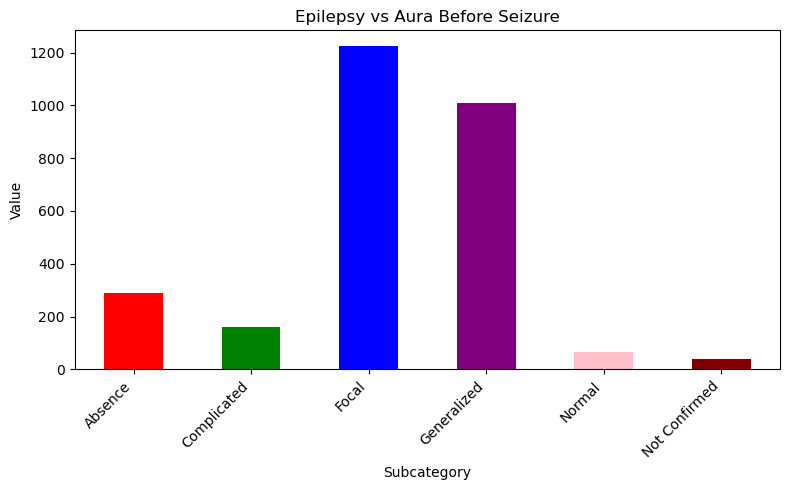

In [61]:
selected_row = p.loc['Aura Before Seizure']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Aura Before Seizure')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

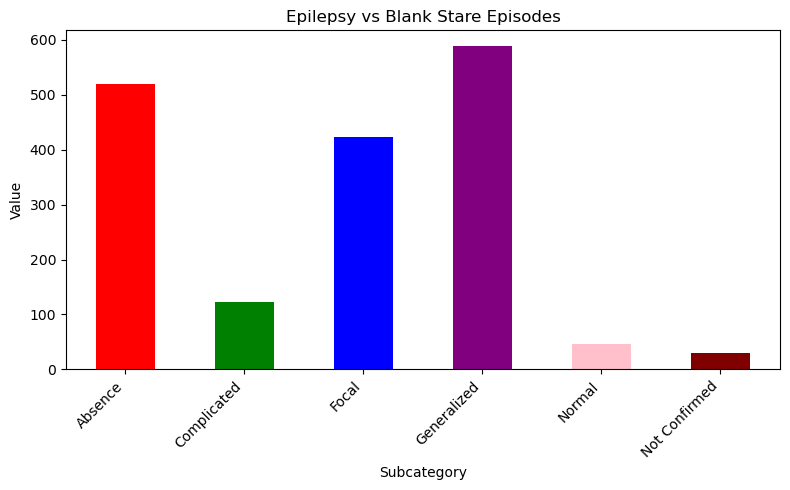

In [69]:
selected_row = p.loc['Blank Stare Episodes']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Blank Stare Episodes')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

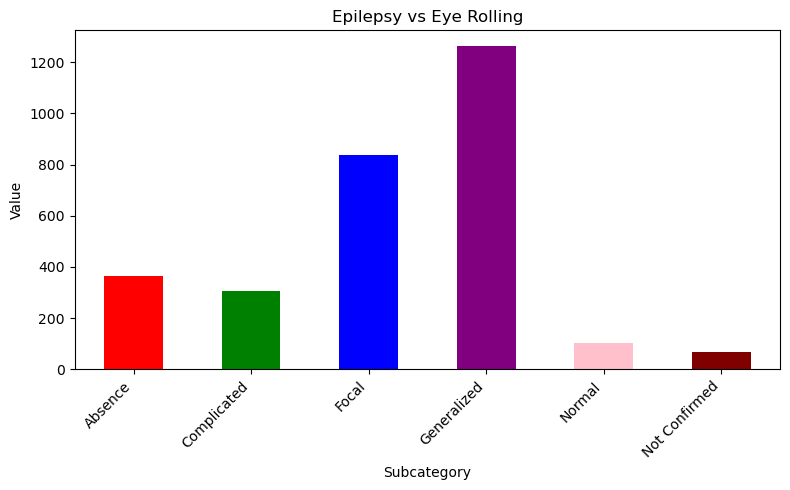

In [65]:
selected_row = p.loc['Eye Rolling']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Eye Rolling')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

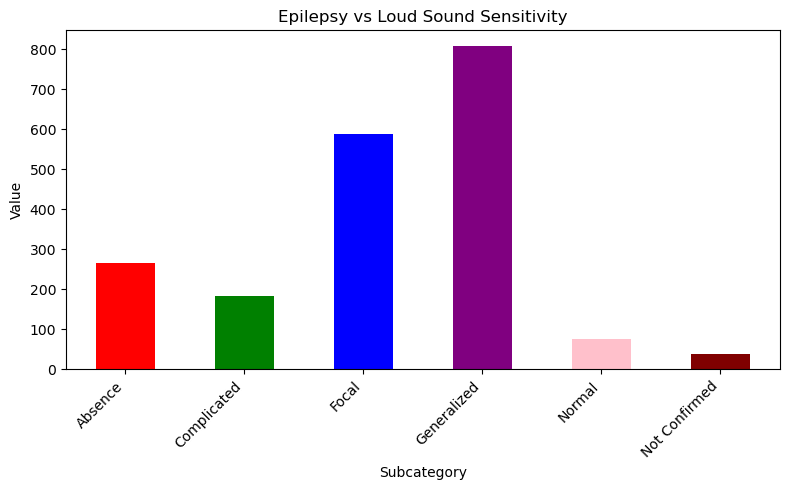

In [67]:
selected_row = p.loc['Loud Sound Sensitivity']
plt.figure(figsize=(8, 5))
selected_row.plot.bar(color = colors)
plt.title(f'Epilepsy vs Loud Sound Sensitivity')
plt.xlabel('Subcategory')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()